# Hydrostatic forces on submerged surfaces

We take our equation (see Lecture 3):

$$\frac{dp}{dz} = -\gamma \qquad\Longrightarrow\qquad p = \gamma h$$

## Tasks:

1. Plot the pressure field, the isobars are horizontal.

2. Integrate $p\,dA$ over a flat gate with ``sympy`` and recover $F_R = \gamma h_c A$.

3. Prove that the centre of pressure sits below the centroid.

Work in SI throughout. Water at 20 °C: $\gamma = 9.80\ \mathrm{kN/m^3}$.

In [76]:
# Import libraries

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [77]:
# Constants

gamma_w = 9.80e3        # specific weight of water, N/m^3
G       = 9.81          # m/s^2

In [78]:
# Specific weight of a liquid of specific gravity SG, in N/m^3.

gamma = lambda SG: SG * gamma_w

In [79]:
# A few examples:
print(f"Water   gamma = {gamma(1.00):8.0f} N/m^3")
print(f"Oil 0.9 gamma = {gamma(0.90):8.0f} N/m^3")
print(f"Mercury gamma = {gamma(13.6):8.0f} N/m^3")

Water   gamma =     9800 N/m^3
Oil 0.9 gamma =     8820 N/m^3
Mercury gamma =   133280 N/m^3


## 1. The pressure field

The gage pressure in a liquid at rest depends on depth only:

$$p(x, h) = \gamma h$$

so the isobars are horizontal lines, whatever the shape of the container. Everything that follows is just this field integrated over some surface.

In [80]:
# Tank depth and width in m

H, W = 4.0, 6.0                                   

# 1D vectors where h is measured down from the surface
x = np.linspace(0, W, 240)
h = np.linspace(0, H, 240)                       

# 2D Meshgrid
x_2d, h_2d = np.meshgrid(x, h)

# pressure in kPa
P = gamma(1.0) * h_2d / 1e3     

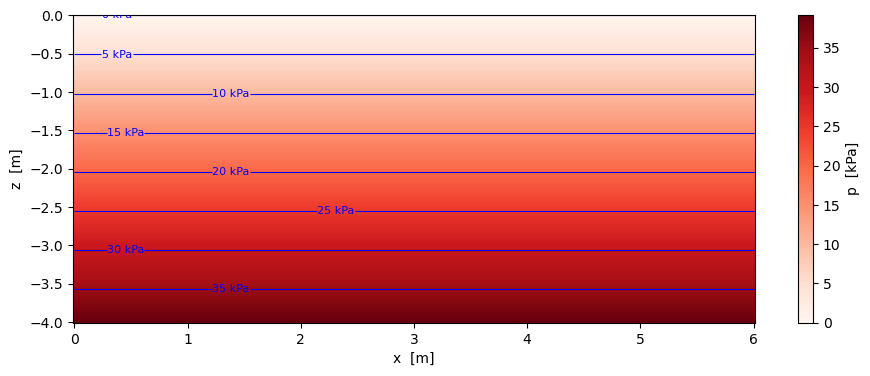

In [81]:
plt.figure(figsize=(11, 4))

z = plt.pcolormesh(x_2d, -h_2d, P, cmap="Reds")

cs = plt.contour(x_2d, -h_2d, P, levels=np.arange(0, 40, 5), colors="b", linewidths=0.8)

plt.clabel(cs, fmt="%.0f kPa", fontsize=8)

plt.xlabel("x  [m]")
plt.ylabel("z  [m]")

plt.colorbar(z, label="p  [kPa]")

plt.show()

### Observations:

- The orizontal lines are isobars.

- The force on a surface reduces to a 1D integral down the depth, however complicated the surface is.

## 2. A vertical rectangular gate:

Take a vertical gate of width $b$ and height $h$, with its top edge at the free surface. Measure $y$ downward from the surface. A horizontal strip at depth $y$ has area $dA = b\,dy$ and carries a pressure $p = \gamma y$, so

$$dF = p\,dA = \gamma\, y\, b\,dy .$$

Let's use SymPy for two integrals: force and its moment.

Remember that for this gate the centroid is at:

$$y_c = h/2$$

and the area is:

$$A = bh$$

The rectangle has $I_{xc} = b h^3/12$:

$$F_R = \gamma h_c A, \qquad y_R = \frac{I_{xc}}{y_c A} + y_c .$$

In [82]:
# Define symbols
gam, y, b, h = sp.symbols('gamma y b h', positive=True)

# Centroid (C)
y_c = h/2

# dFper unit dy
dF = gam * y * b                       

# Integrals
F_R = sp.integrate(dF, (y, 0, h))

y_R = sp.integrate(y * dF, (y, 0, h)) / F_R

# Show results
display("F_R =", sp.simplify(F_R))

display("y_R =", sp.simplify(y_R))

display("y_c =", sp.simplify(y_c))

'F_R ='

b*gamma*h**2/2

'y_R ='

2*h/3

'y_c ='

h/2

### Observations:

- The integrals return $F_R = \gamma b h^2 / 2$ and $y_R = 2h/3$

- The resultant force acts 1/3 of the height above the bottom of the gate, not at the middle. 

In [83]:
# Gate width and height in m
bv, hv = 6.0, 4.0                      

# Get values
vals = {gam: gamma(1.0), b: bv, h: hv}

# Convert to floats
FR = float(F_R.subs(vals))
yR = float(y_R.subs(vals))
yc = float(y_c.subs(vals))

# Show results
print(f"F_R = {FR/1e3:7.1f} kN")
print("\n")
print(f"y_c = {yc:7.3f} m")
print("\n")
print(f"y_R = {yR:7.3f} m   ({hv - yR:.3f} m above the bottom)")
print("\n")
print(f"CP sits {yR - yc:.3f} m below C")
print("\n")

F_R =   470.4 kN


y_c =   2.000 m


y_R =   2.667 m   (1.333 m above the bottom)


CP sits 0.667 m below C




## 3. Drawing the distribution, the centroid and the centre of pressure

Tthe loading grows linearly with depth, the centroid **C** sits at mid-depth, and the centre of pressure **CP** sits below it.

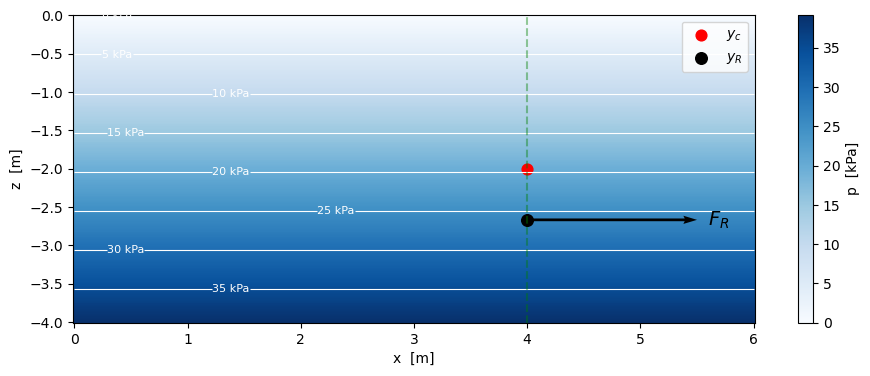

In [84]:
# Plotting
plt.figure(figsize=(11, 4))

z = plt.pcolormesh(x_2d, -h_2d, P, cmap="Blues", shading="auto")

cs = plt.contour(x_2d, -h_2d, P, levels=np.arange(0, 40, 5), colors="w", linewidths=0.8)

plt.clabel(cs, fmt="%.0f kPa", fontsize=8)

plt.axvline(4, color="g", ls="--", lw=1.5, alpha=0.4)

plt.xlabel("x  [m]")
plt.ylabel("z  [m]")

plt.colorbar(z, label="p  [kPa]")

# Add C and CP
plt.scatter(4, -yc, marker="o", s=60, color="red", label=r"$y_c$")
plt.scatter(4, -yR, marker="o", s=70, color="black", label=r"$y_R$")

# Add FR
plt.quiver(4, -yR, 1.5, 0, angles="xy", scale_units="xy", scale=1, color="black", width=0.004)
plt.text(5.6, -yR, r"$F_R$", fontsize=14, va="center")

plt.legend()

plt.show()

## 4. The inclined plane surface

The plane of the surface meets the free surface at $O$ at an angle $\theta$; $y$ is measured down the plane from $O$, so the depth of a point is $h = y\sin\theta$
and:

$$dF = \gamma\, y \sin\theta \; dA .$$

Take a rectangle of width $b$ whose top edge is at $y_1$ down the plane and whose length along the plane is $L$. Everything is 1D again.

In [85]:
# Same method, define sybols first
th, L, y1 = sp.symbols('theta L y_1', positive=True)

# dF, then integrate
dF  = gam * y * sp.sin(th) * b
F_R = sp.integrate(dF,     (y, y1, y1 + L))
y_R = sp.integrate(y * dF, (y, y1, y1 + L)) / F_R

# Centroid, down the plane
y_c = y1 + L/2                         

display("F_R =", sp.simplify(F_R))

display("y_R =", sp.simplify(y_R))

display("F_R - gamma h_c A =", sp.simplify(F_R - gam * y_c * sp.sin(th) * b * L))

'F_R ='

L*b*gamma*(L + 2*y_1)*sin(theta)/2

'y_R ='

2*(L**2 + 3*L*y_1 + 3*y_1**2)/(3*(L + 2*y_1))

'F_R - gamma h_c A ='

0

In [86]:
# Get offset, i.e. = I_xc / (y_c A)

offset = sp.simplify(y_R - y_c)                     

display("y_R - y_c =", offset)

f = sp.lambdify((y1, L), offset, "numpy")

'y_R - y_c ='

L**2/(6*(L + 2*y_1))

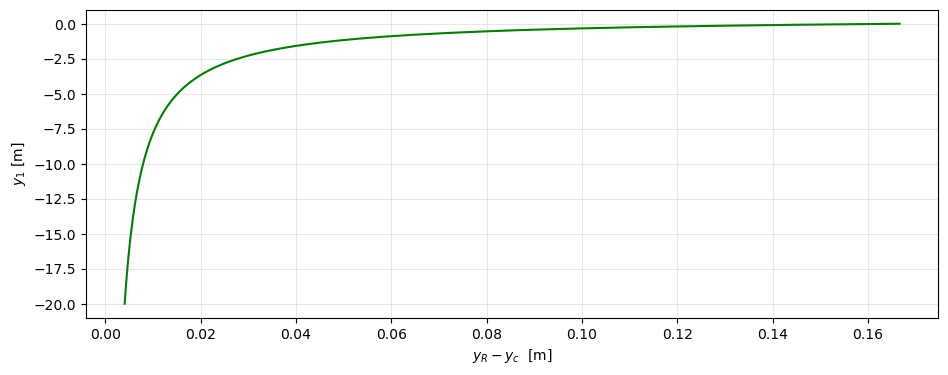

In [87]:
# Fix L
L_value = 1.0

y1s  = np.linspace(0.0, 20.0, 300)

plt.figure(figsize=(11, 4))

plt.plot(f(y1s, L_value), -y1s, color="green")

plt.ylabel("$y_1$ [m]")
plt.xlabel("$y_R - y_c$  [m]")

plt.grid(alpha=0.3)

plt.show()

### Observations:

- $F_R = \gamma h_c A$ contains $\theta$ only through the depth of the centroid.

- If we rotate the plate about its centroid, keeping that depth fixed, and the force does not change.

- The offset of the centre of pressure below the centroid is $I_{xc}/(y_c A)$, which shrinks as $y_c$ grows.

- Deep surfaces feel an almost uniform pressure, so $CP$ approaches $C$.